<a href="https://colab.research.google.com/github/LeeSeongJinn/Doosan_Rokey_bootcamp/blob/main/2_Applied_AI/Day12/1_YOLOv8_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# YOLO V8 기본 실습

In [ ]:
# YOLOv8 설치 (Ultralytics)
!pip install -q ultralytics

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from ultralytics import YOLO

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.11.0+cu128
Device: cuda


In [ ]:
# 사전 학습된 COCO 모델 다운로드 (자동)
# n: nano(가장 빠름) s:small, m: medium l: large, x: extra large

model = YOLO('yolov8n.pt')

In [ ]:
print(f'Number of model parameters: {sum(p.numel() for p in model.model.parameters())}')

Number of model parameters: 3157200


In [ ]:
 # COCO 클래스 (80개)

class_names = model.names
print(f'총 클래스 수: {len(class_names)}')
print(f'일부 클래스: {list(class_names.values())[:10]}')

총 클래스 수: 80
일부 클래스: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [ ]:
# 테스트 이미지 준비

def download_image(url):
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img

    except Exception as e:
        print(f'Error downloading image: {e}')
        return None

In [ ]:
test_images = {
    'street': 'https://ultralytics.com/images/bus.jpg',
    'people': 'https://ultralytics.com/images/zidane.jpg',
    'animals': 'https://images.unsplash.com/photo-1583337130417-3346a1be7dee?w=640',
}

  street: (810, 1080)
  people: (1280, 720)
  animals: (640, 800)


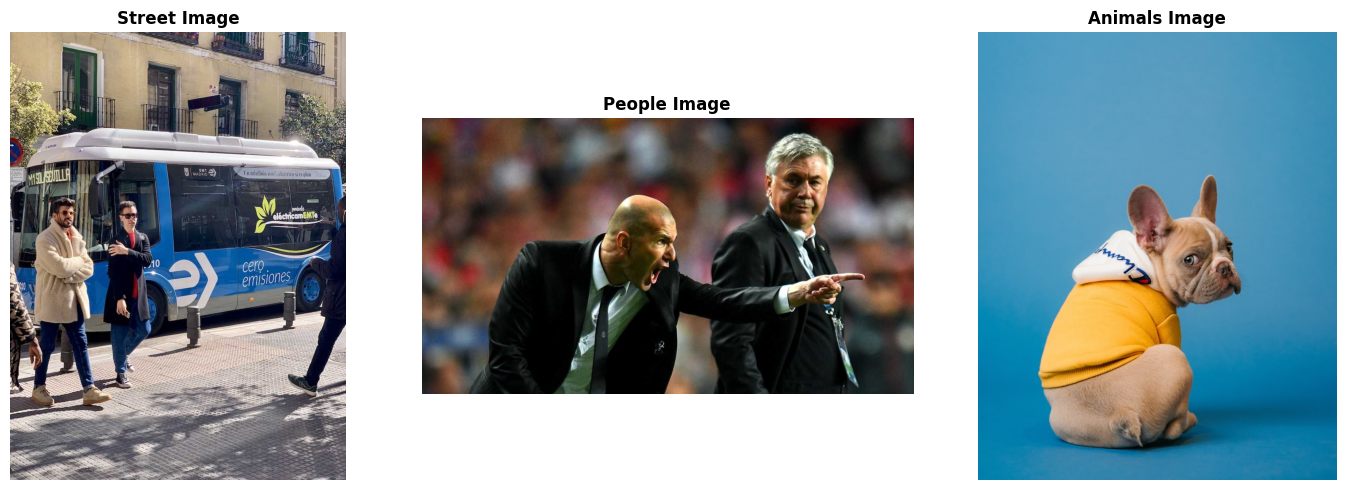

In [ ]:
images = {}
for name, url in test_images.items():
    img = download_image(url)
    if img is not None:
        images[name] = img
        print(f"  {name}: {img.size}")

# 샘플 이미지 시각화
if images:
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    if len(images) == 1:
        axes = [axes]

    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img)
        ax.set_title(f'{name.capitalize()} Image', fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# 기본 객체 검출

# 첫번재 이미지로 검출
images.keys()

dict_keys(['street', 'people', 'animals'])

In [ ]:
list(images.keys())[0]

'street'

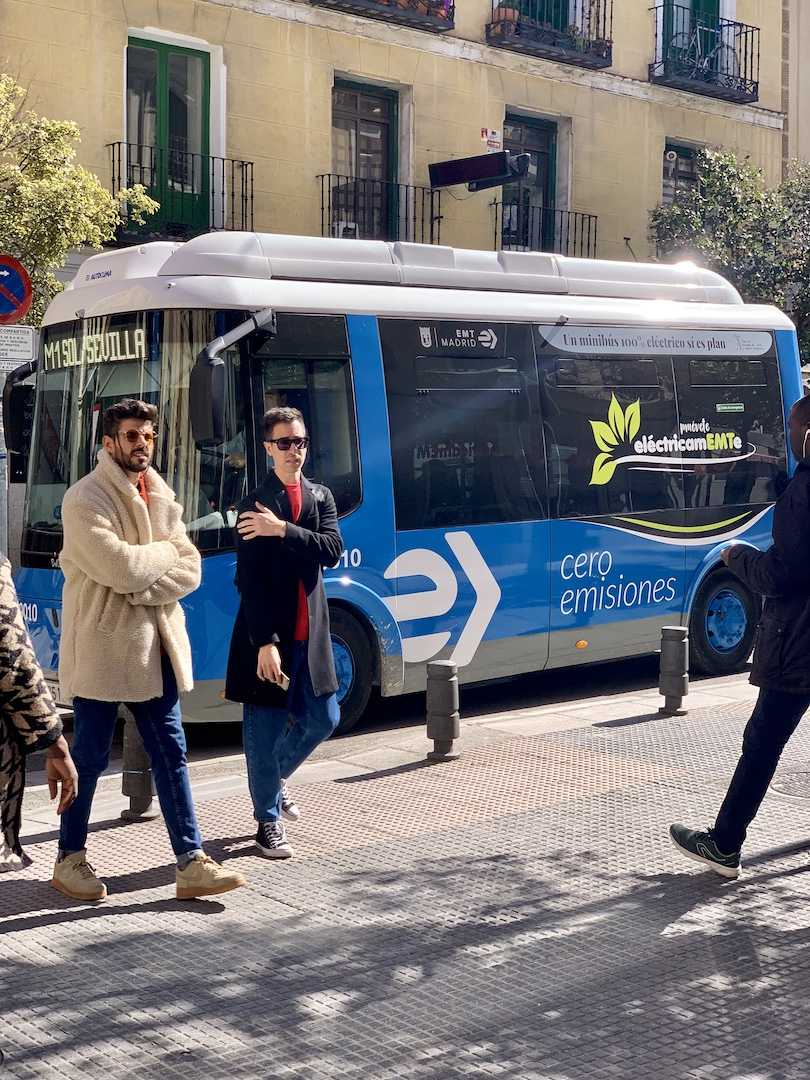

In [ ]:
img_name = list(images.keys())[0]
test_img = images[img_name]
test_img

In [ ]:
# yolo v8 추론
results = model(test_img)

# 결과 추출
result = results[0] # 첫번째 결과
boxes = result.boxes

len(boxes) #  검출된 객체수

# 검출 결과 상세 정보
if len(boxes) > 0:
    print("검출상세정보")
    for i, box in enumerate(boxes):
        # 박스 정보
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().item()
        cls = int(box.cls[0].cpu().item())
        class_name = class_names[cls]

        print(f" {i+1}. {class_name}: {conf:.3f} "
              f"[{x1:.0f},{y1:.0f},{x2:.0f},{x2:.0f}]"
        )


0: 640x480 4 persons, 1 bus, 1 stop sign, 7.5ms
Speed: 2.5ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
검출상세정보
 1. bus: 0.873 [23,231,805,805]
 2. person: 0.866 [49,399,245,245]
 3. person: 0.853 [669,392,810,810]
 4. person: 0.825 [222,406,345,345]
 5. person: 0.261 [0,551,63,63]
 6. stop sign: 0.256 [0,254,33,33]


Yolo v8 결과 해석 하는 법


```
형식,명칭,설명
xywh,Center Coordinates,"상자의 **중심점(x, y)**과 너비(w), 높이(h) (픽셀 단위)"
- xywh: tensor([[413.9255, 494.0521, 782.1035, 525.5683]
xywhn,Normalized Center,위 데이터를 이미지의 전체 크기(1.0) 대비 비율로 정규화한 값
- xywhn: tensor([[0.5110, 0.4575, 0.9656, 0.4866],
xyxy,Corner Coordinates,"상자의 **좌측 상단(x1, y1)**과 우측 하단(x2, y2) (픽셀 단위)"
- xyxy: tensor([[2.2874e+01, 2.3127e+02, 8.0498e+02, 7.5684e+02],
xyxyn,Normalized Corner,위 데이터를 이미지 전체 크기 대비 비율로 정규화한 값
- xyxyn: tensor([[2.8239e-02, 2.1414e-01, 9.9380e-01, 7.0077e-01],
```


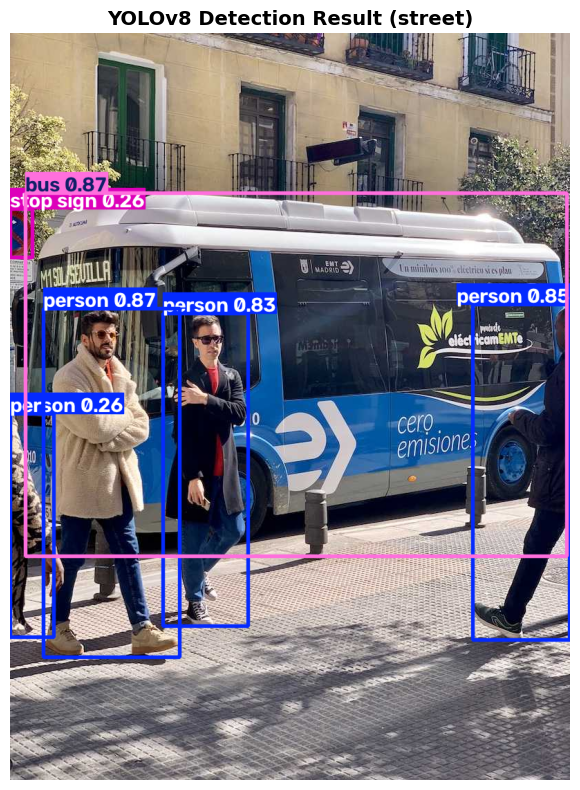

In [ ]:
# 결과 시각화(기본)
import cv2

result_img = result.plot() # BGR 형식

# RGB 로 변환
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLOv8 Detection Result ({img_name})',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

confidence threshold 조정


0: 640x480 4 persons, 1 bus, 1 stop sign, 8.3ms
Speed: 2.5ms preprocess, 8.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 3 persons, 1 bus, 8.2ms
Speed: 2.4ms preprocess, 8.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 3 persons, 1 bus, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


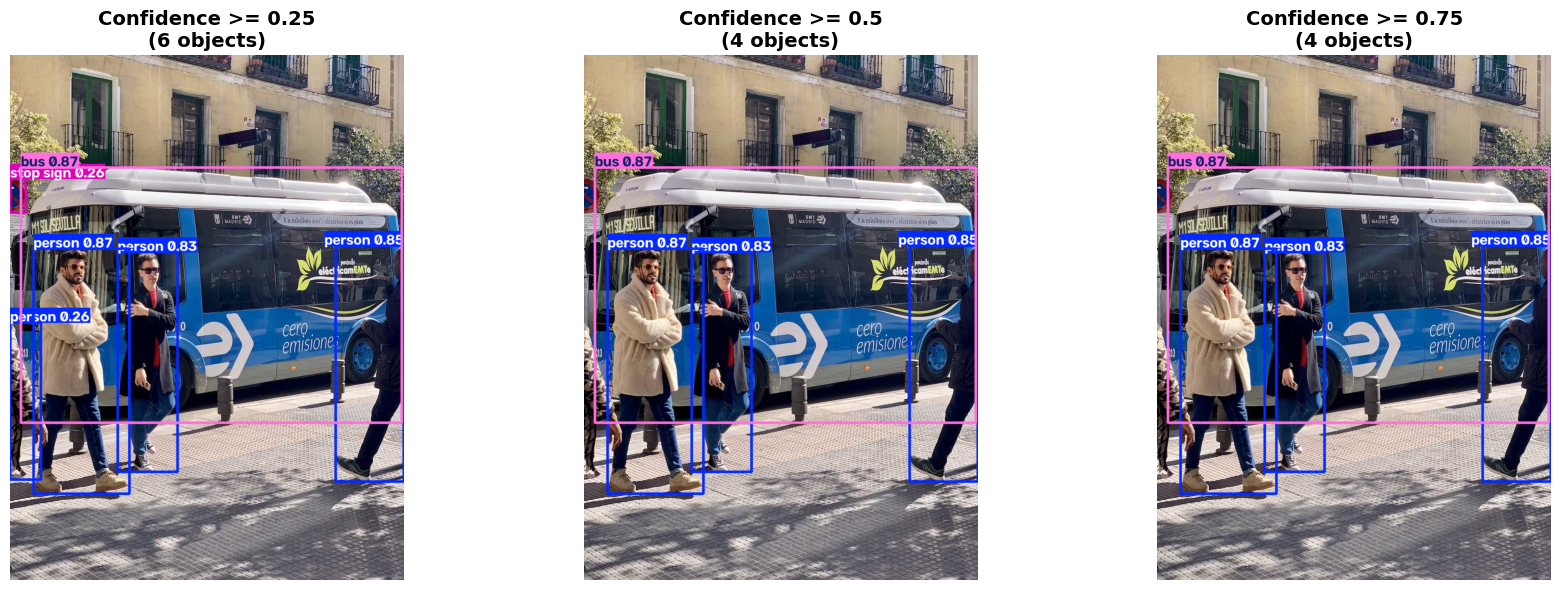

In [ ]:
thresholds = [0.25, 0.5, 0.75]
fig, axes = plt.subplots(1,3, figsize=(18, 6))

for ax, conf_thresh in zip(axes, thresholds):
    # threshold 적용하여 추론
    results_thresh = model(test_img, conf=conf_thresh)
    result_thresh = results_thresh[0]

    # 시각화
    img_plot = result_thresh.plot()
    ax.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Confidence >= {conf_thresh}\n'
             f'({len(result_thresh.boxes)} objects)',
             fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


0: 640x480 3 persons, 1 bus, 8.3ms
Speed: 2.5ms preprocess, 8.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 2 persons, 104.1ms
Speed: 1.3ms preprocess, 104.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 640x512 1 dog, 97.8ms
Speed: 1.8ms preprocess, 97.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 512)


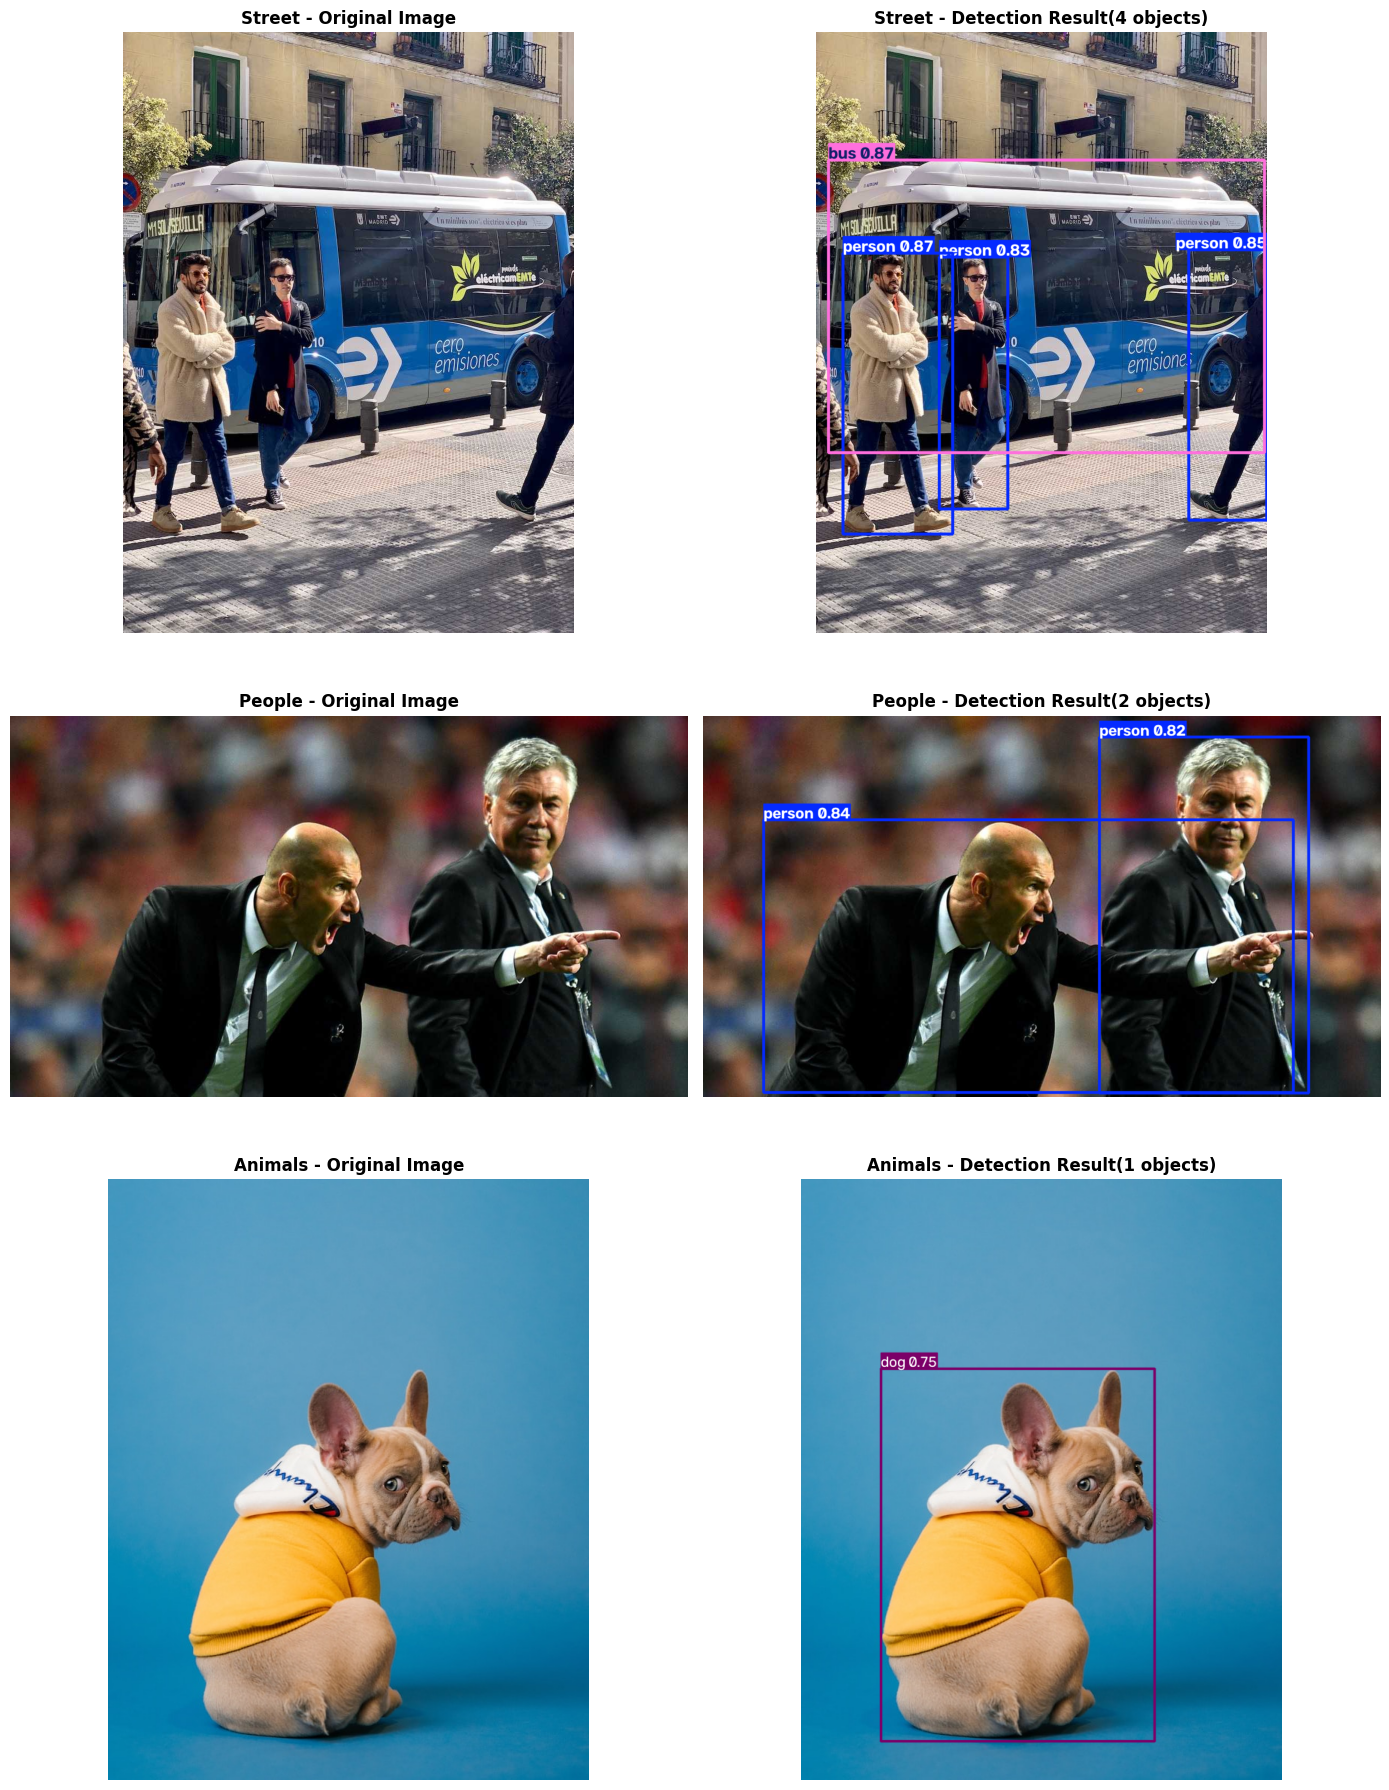

In [ ]:
# 여러 이미지 일괄 검출

fig, axes = plt.subplots(len(images), 2, figsize=(14, 6*len(images)))

if len(images) == 1:
    axes = axes.reshape(1, -1)

for idx, (name, img) in enumerate(images.items()):
    # 원본 이미지
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'{name.capitalize()} - Original Image',
                           fontsize=12, fontweight='bold')
    axes[idx, 0].axis('off')

    # 검출 결과
    results = model(img, conf=0.5)
    result_img = results[0].plot()
    axes[idx, 1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axes[idx, 1].set_title(f'{name.capitalize()} - Detection Result({len(results[0].boxes)} objects)',
                           fontsize=12, fontweight='bold')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 클래스 별 통계 분석

# 모든 이미지에서 검출 수행
all_detections = {}

for name, img in images.items():
    results = model(img, conf=0.5)
    boxes = results[0].boxes

    detections = []
    for box in boxes:
        cls = int(box.cls[0].cpu().item())
        conf = box.conf[0].cpu().item()
        detections.append({
            'class': class_names[cls],
            'confidence': conf
        })

    all_detections[name] = detections

# 클래스별 카운트
from collections import Counter

for name, detections in all_detections.items():
    print(f'\n{name.upper()} 이미지:')
    class_counts = Counter([det['class'] for det in detections])
    for cls, count in class_counts.most_common():
        avg_conf = np.mean([det['confidence']
                            for det in detections if det['class'] == cls])
        print(f'   - {cls}: {count}개 (평균 confidence: {avg_conf:.3f})')


0: 640x480 3 persons, 1 bus, 9.2ms
Speed: 2.8ms preprocess, 9.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 2 persons, 8.6ms
Speed: 1.4ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 640x512 1 dog, 7.7ms
Speed: 1.8ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

STREET 이미지:
   - person: 3개 (평균 confidence: 0.848)
   - bus: 1개 (평균 confidence: 0.873)

PEOPLE 이미지:
   - person: 2개 (평균 confidence: 0.827)

ANIMALS 이미지:
   - dog: 1개 (평균 confidence: 0.754)



0: 640x480 4 persons, 1 bus, 1 stop sign, 9.0ms
Speed: 2.5ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


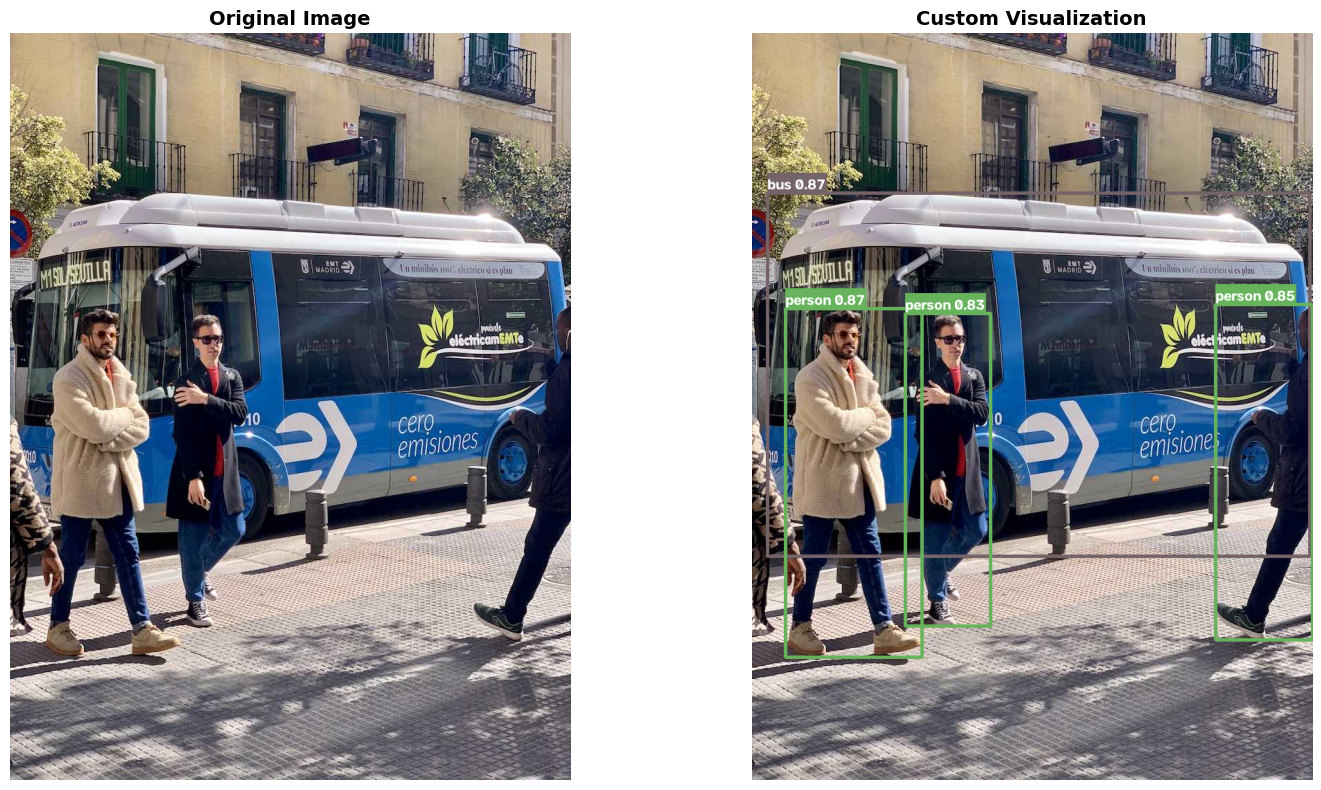

In [ ]:
# 커스텀 시각화

def draw_custom_boxes(image, results, conf_threshold=0.5):
    img_np = np.array(image).copy()
    boxes = results[0].boxes

    # 색상 팔레트 (클래스별)
    np.random.seed(42)
    colors = {cls: tuple(np.random.randint(0, 255, 3).tolist())
              for cls in range(len(class_names))}

    for box in boxes:
        conf = box.conf[0].cpu().item()
        if conf < conf_threshold:
            continue

        # 박스 정보
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls[0].cpu().item())
        class_name = class_names[cls]
        color = colors[cls]

        # 박스 그리기
        cv2.rectangle(img_np, (x1, y1), (x2, y2), color, 3)

        # 레이블 배경
        label = f'{class_name} {conf:.2f}'
        (text_w, text_h), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img_np, (x1, y1 - text_h - 10),
                     (x1 + text_w, y1), color, -1)

        # 레이블 텍스트
        cv2.putText(img_np, label, (x1, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_np

# 커스텀 시각화 적용
img_name = list(images.keys())[0]
test_img = images[img_name]
results = model(test_img)

custom_img = draw_custom_boxes(test_img, results, conf_threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(test_img)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(custom_img)
axes[1].set_title('Custom Visualization', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 모델 정보 및 성능 비교

model_info = {
    'YOLOv8n': {'params': '3.2M', 'mAP': 37.3, 'speed': '80+ FPS'},
    'YOLOv8s': {'params': '11.2M', 'mAP': 44.9, 'speed': '50+ FPS'},
    'YOLOv8m': {'params': '25.9M', 'mAP': 50.2, 'speed': '30+ FPS'},
    'YOLOv8l': {'params': '43.7M', 'mAP': 52.9, 'speed': '20+ FPS'},
    'YOLOv8x': {'params': '68.2M', 'mAP': 53.9, 'speed': '15+ FPS'},
}

model_info.items()

print('\n|  모델  |  파라미터  |  mAP  |  속도  |')
for model_name, info in model_info.items():
    print(f'{model_name} | {info['params']} | {info['mAP']}% | {info['speed']}')


|  모델  |  파라미터  |  mAP  |  속도  |
YOLOv8n | 3.2M | 37.3% | 80+ FPS
YOLOv8s | 11.2M | 44.9% | 50+ FPS
YOLOv8m | 25.9M | 50.2% | 30+ FPS
YOLOv8l | 43.7M | 52.9% | 20+ FPS
YOLOv8x | 68.2M | 53.9% | 15+ FPS


In [ ]:
# 배치 추론 (여러 이미지 동시 처리)

import time

# 이미지 리스트 준비
img_list = list(images.values())

# 단일 추론
start_time = time.time()
for img in img_list:
    _ = model(img, verbose=False)
single_time = time.time() - start_time

# 배치 추론
start_time = time.time()
_ = model(img_list, verbose=False)
batch_time = time.time() - start_time

print(f"단일 추론: {single_time:.3f}초 ({len(img_list)}개 이미지)")
print(f"배치 추론: {batch_time:.3f}초 ({len(img_list)}개 이미지)")
print(f"속도 향상: {single_time/batch_time:.2f}배")

단일 추론: 0.054초 (3개 이미지)
배치 추론: 0.132초 (3개 이미지)
속도 향상: 0.41배



파일 선택 창이 열립니다...


Saving karina.jpg to karina.jpg
이미지 업로드 완료: karina.jpg
크기: (640, 820)

0: 640x512 2 persons, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 512)


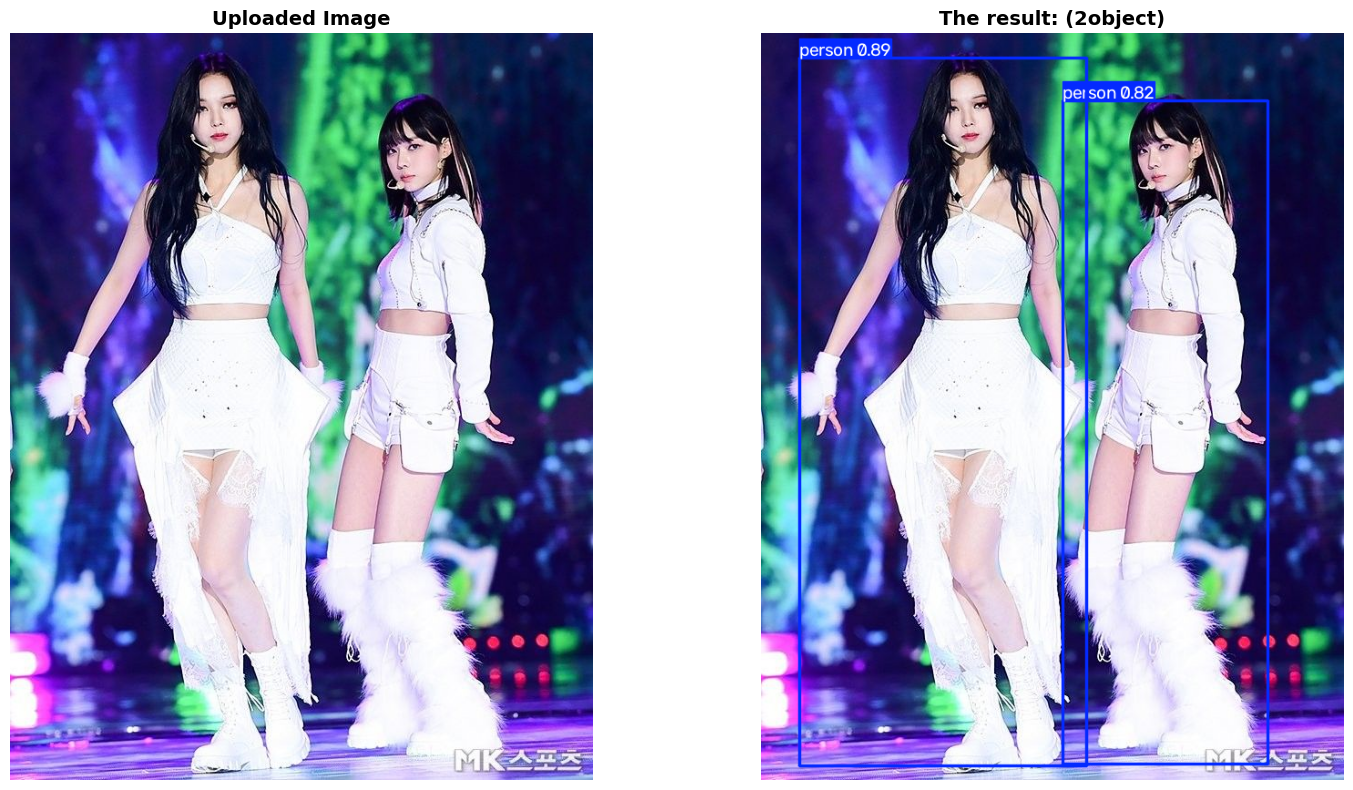


검출된 객체:
  1. person: 0.887
  2. person: 0.825


In [ ]:
# Colab 파일 업로드 기능

from google.colab import files

print("\n파일 선택 창이 열립니다...")
uploaded = files.upload()

if uploaded:
    # 업로드된 첫 번째 이미지 사용
    img_path = list(uploaded.keys())[0]
    user_img = Image.open(img_path).convert('RGB')

    print(f"이미지 업로드 완료: {img_path}")
    print(f"크기: {user_img.size}")

    # 검출 수행
    results = model(user_img, conf=0.5)
    result_img = results[0].plot()

    # 결과 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(user_img)
    axes[0].set_title('Uploaded Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'The result: ({len(results[0].boxes)}object)',
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # 검출 상세 정보
    print("\n검출된 객체:")
    for i, box in enumerate(results[0].boxes):
        cls = int(box.cls[0].cpu().item())
        conf = box.conf[0].cpu().item()
        print(f"  {i+1}. {class_names[cls]}: {conf:.3f}")
else:
    print("업로드된 이미지가 없습니다.")